# Multi-Head Attention

## Start with the problem: one matching space may miss useful relationships

A token can participate in several relationships at once. In a sentence, one relationship might connect an action to an object while another links a pronoun to an earlier mention. In a sensor sequence, one useful pattern might be a recent change and another a longer recurring behavior.

A single attention head compares queries and keys in one projected feature space. **Multi-head attention** learns several projected spaces, performs a read in each, then concatenates and mixes the outputs. The additional spaces provide flexibility; they do not guarantee that each head learns a distinct human-readable role.

We will construct two heads numerically, trace batch and feature dimensions, join the outputs, and inspect masks and parameter counts. The [code companion](29_Multi_Head_Attention.ipynb) splits projected tensors into two heads, verifies weight normalization, joins their reads, and inspects a library layer's output shape.

Review [Attention Mechanism](26_Attention_Mechanism_Notes.ipynb) for the softmax read and [Transformers](27_Transformers_Notes.ipynb) for how the result enters a residual block.


## Follow parallel reads into one representation

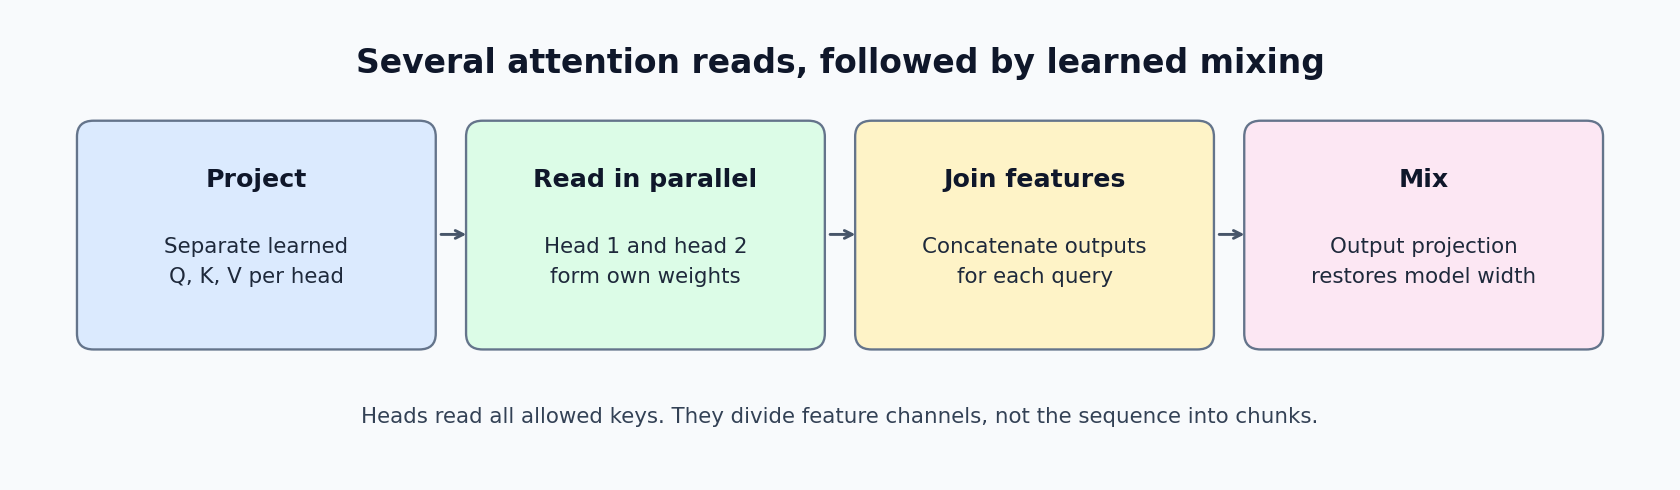

For head $j$:

$$Q_j=X_qW_j^Q,\qquad K_j=X_kW_j^K,\qquad V_j=X_vW_j^V,$$
$$H_j=\operatorname{softmax}\left(\frac{Q_jK_j^T}{\sqrt{d_k}}+M_j\right)V_j.$$

The combined result is:

$$O=\operatorname{Concat}(H_1,\ldots,H_h)W^O.$$

Here $h$ is the head count, and concatenation joins feature coordinates for the **same query position**. It does not append one head's positions after another head's positions. The output projection learns combinations of the joined features.

The queries determine the output positions. Every head can read all keys allowed by its mask. Splitting into heads divides projected feature channels, not the sequence into disjoint chunks.


## Distinguish input width, head width, and head count

A common implementation uses model width $D$ and head count $h$, with equal query/key/value head width $d=D/h$. This requires $D$ to be divisible by $h$ in that implementation.

| Configuration | Model width $D$ | Heads $h$ | Per-head width $d$ |
| --- | --- | --- | --- |
| One wide head | 8 | 1 | 8 |
| Companion | 8 | 2 | 4 |
| Four narrow heads | 8 | 4 | 2 |

At fixed model width, adding heads narrows each head. It does not multiply the final output width, because the concatenated head widths still total $D$.

The mathematical attention operation can use other query/key/value widths, but the layer's implementation determines which combinations are supported. Keep the simple equal-width case explicit before generalizing it.

Each head uses scaling by its own key width $\sqrt{d_k}$. Dividing by $\sqrt D$ after splitting into narrower heads would change the score scale and therefore the weights.


## Project features before splitting them into heads

A practical layer often computes full-width projections:

$$Q=X_qW^Q,\qquad K=X_kW^K,\qquad V=X_vW^V,$$

then reshapes each width-$D$ row into $h$ groups of width $d$. The columns assigned to a head correspond to that head's learned projection features.

For a width-eight row $[a,b,c,d,e,f,g,h]$ split into two heads, the first head receives $[a,b,c,d]$ and the second $[e,f,g,h]$. These are coordinates of the **projected** row, not necessarily the first and last halves of the raw input features.

| Step | What changes |
| --- | --- |
| Learned projection | Feature content and geometry |
| Reshape | Logical grouping of channels |
| Transpose | Axis order for batched matrix multiplication |
| Attention | Content-dependent reads across positions |

Reshape alone does not learn a new feature space. The preceding projection gives the head channels their learned meanings. The companion starts its manual calculation with tensors already serving as query, key, and value features, so its split is a shape demonstration.


## Construct two small heads from an identity input

Use two input positions with rows $x_1=[1,0]$ and $x_2=[0,1]$. Select scalar projections as follows:

| Projection | Head 1 column | Head 2 column |
| --- | --- | --- |
| Query $W_j^Q$ | $[1,0]^T$ | $[0,1]^T$ |
| Key $W_j^K$ | $[1,0]^T$ | $[0,1]^T$ |
| Value $W_j^V$ | $[2,6]^T$ | $[10,20]^T$ |

Thus head 1 has queries $[1,0]$, keys $[1,0]$, and values $[2,6]$. Head 2 has queries $[0,1]$, keys $[0,1]$, and values $[10,20]$. Each head width is one, so its scaling denominator is one.

These selected projections make the arithmetic clear. They are not copied from the companion's randomly initialized layer and do not describe trained semantic roles. Because the input matrix is the identity, each projection column's entries appear directly as the projected rows.


## Calculate every read in both heads

Head 1 scores are $[[1,0],[0,0]]$. Head 2 scores are $[[0,0],[0,1]]$. Normalize each row independently over its two keys:

| Head | Query position | Scores | Weights | Weighted value read |
| --- | --- | --- | --- | --- |
| 1 | 1 | $[1,0]$ | $[0.731059,0.268941]$ | 3.075766 |
| 1 | 2 | $[0,0]$ | $[0.5,0.5]$ | 4.000000 |
| 2 | 1 | $[0,0]$ | $[0.5,0.5]$ | 15.000000 |
| 2 | 2 | $[0,1]$ | $[0.268941,0.731059]$ | 17.310586 |

For head 1 at the first position, the output is $0.731059(2)+0.268941(6)\approx3.075766$. Head 2's first query is zero, so its scores are equal and its output is the mean of ten and twenty.

Each query/head pair owns a separate distribution. A row's weights sum to one; summing weights across all heads or all queries is not the normalization condition.

The two heads are different because their projections are different, not because we attached names like “grammar head” or “memory head.” Such labels would require evidence from an actual trained model.


## Concatenate by position, then apply the output projection

The reads join into:

$$J=\begin{bmatrix}3.075766&15\\4&17.310586\end{bmatrix}.$$

Choose an output projection with no bias:

$$W^O=\begin{bmatrix}1&0.5\\0.1&1\end{bmatrix}.$$

For the first query, the final coordinates are:

$$o_{1,1}=3.075766+0.1(15)=4.575766,$$
$$o_{1,2}=0.5(3.075766)+15=16.537883.$$

For the second query, they are approximately $[5.731059,19.310586]$.

| Stage | First query | Second query |
| --- | --- | --- |
| Joined head reads | $[3.075766,15]$ | $[4,17.310586]$ |
| Projected output | $[4.575766,16.537883]$ | $[5.731059,19.310586]$ |

The output projection mixes head features within each query position. It does not perform another attention read over sequence positions. It can also change value ranges, so the final projected output is not constrained to be a convex combination of the original values.


## Follow a loss into a mixing coefficient

To isolate learning after concatenation, use the first query's head outputs $a=3.075766$ and $b=15$. Let one scalar prediction be $\hat y=a+wb$ with $w=0.1$, giving $\hat y\approx4.575766$.

For target four, squared error is $(\hat y-4)^2\approx0.331506$. The gradient of the mixing coefficient is:

$$\frac{\partial L}{\partial w}=2(\hat y-4)b\approx17.272971.$$

With learning rate 0.001, $w$ becomes approximately 0.082727. The new prediction is approximately 4.316671, reducing this single-example loss to about 0.100281.

This selected example updates one output-mixing coefficient while holding head reads fixed. Full training also changes the remaining output weights, biases, queries, keys, values, and upstream representations. Gradients reaching a joined feature route back to the head that produced it.

The output projection therefore does real learned work: it decides how to use the combined reads for the task. Concatenation alone only makes the reads available side by side.


## Trace the companion's batch and head axes

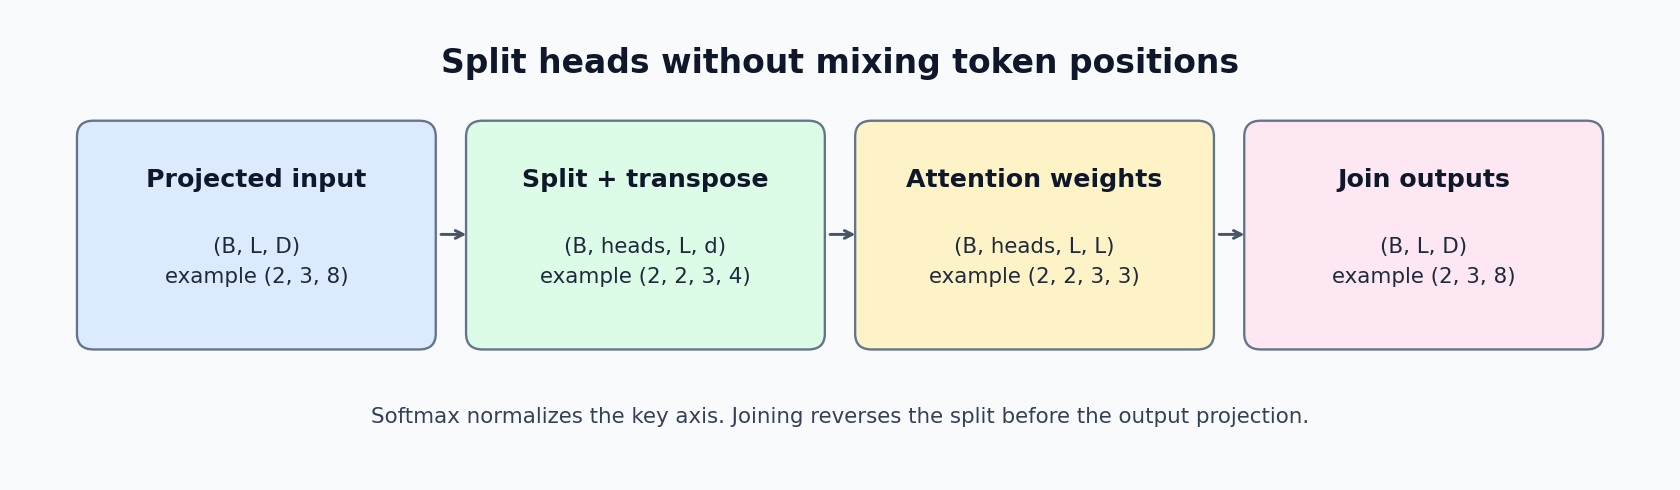

The companion uses $B=2$, $L=3$, $D=8$, and $h=2$, so $d=4$.

| Object | Shape | Meaning |
| --- | --- | --- |
| Projected query/key/value | $(2,3,8)$ | Batch, positions, features |
| Reshaped tensor | $(2,3,2,4)$ | Batch, positions, heads, head features |
| Transposed head tensor | $(2,2,3,4)$ | Batch, heads, positions, features |
| Scores/weights | $(2,2,3,3)$ | One key comparison per query and head |
| Context | $(2,2,3,4)$ | Per-head read for each query |
| Joined output | $(2,3,8)$ | Head features restored per position |

The final transpose returns to batch, position, head, feature order before flattening head and feature dimensions. Flattening the head-major tensor directly would mix the ordering of positions and channels.

The code uses `.contiguous()` before `.view()` after transposing the context. A transpose changes strides; compatible storage layout matters when viewing a tensor as a new shape.


## Generalize to cross-attention with unequal lengths

For query length $L_q$ and key/value length $L_k$, the head tensors have shapes:

| Object | Shape |
| --- | --- |
| Queries | $(B,h,L_q,d_k)$ |
| Keys | $(B,h,L_k,d_k)$ |
| Values | $(B,h,L_k,d_v)$ |
| Weights | $(B,h,L_q,L_k)$ |
| Per-head output | $(B,h,L_q,d_v)$ |

Two decoder positions reading three source positions produce a $2\times3$ score matrix in every head. The result still has two query-position outputs. Key and value lengths must match, but query length may differ.

The companion's `split_heads` helper captures one shared `length` variable, which suits its equal-length example. A general cross-attention helper must use each tensor's own sequence length. Reusing a self-attention reshape with unequal lengths can fail or silently assign the wrong axes if the element counts happen to fit.

[Transformer Encoder and Decoder](30_Transformer_Encoder_and_Decoder_Notes.ipynb) shows where these rectangular attention matrices occur.


## Broadcast masks over the intended dimensions

A self-attention causal mask has query-by-key shape $(L,L)$. A padding mask identifies invalid keys for each example, often shape $(B,L_k)$. Their combined logical relation must reach every intended head without confusing batch and query axes.

For two positions, an additive causal matrix is $[[0,-\infty],[0,0]]$. In the selected two-head example, both first-position reads become their first value: two in head 1 and ten in head 2. The second-position reads retain both available keys.

| Relationship | Blocked positions |
| --- | --- |
| Causal self-attention | Future keys for each query |
| Key padding | Artificial key/value positions |
| Restricted cross-attention | Source positions unavailable to that query |

In PyTorch `nn.MultiheadAttention`, Boolean masks use `True` for blocking. A two-dimensional attention mask is shared across the batch, and a per-example/head three-dimensional mask follows the layer's documented layout. See the [official mask and output specifications](https://docs.pytorch.org/docs/stable/generated/torch.nn.MultiheadAttention.html).

Do not assume that a mask with valid dimensions encodes the correct rule. Inspect its allowed relationships on a tiny example, especially when porting between APIs.


## Compare parameters and computation at fixed width

For matching input and output width $D$, four dense projections—query, key, value, and output—contribute $4D^2$ weights. If each has a width-$D$ bias, add $4D$ parameters. At $D=8$, that gives $256+32=288$.

Splitting the same full-width projections into more heads does not automatically increase that standard parameter count. Instead, it changes how feature channels are partitioned and how many separate softmax distributions are computed.

| At fixed model width | One head | More equal-width heads |
| --- | --- | --- |
| Width per head | $D$ | $D/h$ |
| Joined value width | $D$ | $D$ |
| Standard projection count | $4D^2$ weights | $4D^2$ weights |
| Materialized score elements | $BL_qL_k$ | $BhL_qL_k$ |

Dense score/value arithmetic remains roughly proportional to $BL_qL_kD$ in this fixed-total-width configuration, while score storage and kernel behavior can vary with head count. Different input widths, optional parameters, or specialized attention designs change these assumptions.


## Interpret head patterns cautiously

Several heads may learn complementary reads, similar reads, or patterns that are difficult to describe. The architecture permits specialization but does not assign it. Head redundancy can occur, and more heads do not imply more independent reasoning processes.

Averaging attention weights across heads can hide a sharp pattern in one head or make very different reads look similar. Inspect individual heads when investigating the computation, while recognizing that the final prediction also depends on values, output projection, residual paths, and later layers.

Head visualizations are intermediate evidence, not complete causal explanations. To test whether a head matters for a task, use an explicit evaluation intervention and measure the resulting behavior. Even that result depends on the rest of the model's ability to compensate.

For model selection, compare held-out quality and measured resource use under the same data and training protocol. Select head count because it helps the experiment, rather than because a diagram contains more parallel boxes.


## Understand what the companion checks and what it leaves separate

The manual part initializes query, key, and value tensors, splits their width into heads, calculates scaled scores, normalizes over keys, reads values, and joins the results. Its assertions check the weight and output shapes and row sums.

The library part creates a separate `nn.MultiheadAttention` layer with its own learned projections and checks its output shape. It does not copy those parameters into the manual computation or assert that the manual and library outputs are numerically identical.

To compare their numbers, the same projections, biases, scaling, masks, and output transform must be applied to both paths. A shape match alone is not an equality check. The initialized tensors also do not represent a trained task, so neither calculation establishes useful prediction performance.

These distinctions make the notebook a clear mechanics lesson: understand the axes first, then align actual parameters if implementing an equivalent layer.


## Diagnose shape and meaning mistakes

| Mistake | Consequence | Check |
| --- | --- | --- |
| Split raw channels without the intended projections | Different matching spaces | Locate projection step |
| Normalize over queries | Wrong read distribution | Softmax on key axis |
| Join before reversing the head transpose | Position/channel mixing | Track axis order |
| Scale by model width instead of head key width | Different concentration | Use $\sqrt{d_k}$ |
| Reuse equal-length reshape for cross-attention | Wrong dimensions | Read each sequence length |
| Expect manual and initialized library outputs to match | Unmatched parameterization | Align projections and output transform |

Test mask behavior with a future-token edit: earlier causal outputs should not change when only unavailable future content changes, assuming all upstream operations respect the same information contract. For padding, compare an example alone and in a padded batch with correctly supplied masks.

These behavioral checks reveal errors that a valid tensor shape can conceal.


## Practice the heads and retain the full operation

1. With model width twelve and three equal-width heads, what is each head's width?
2. For batch two, four heads, five queries, and seven keys, what shape do the weights have?
3. Do heads divide the sequence into separate position chunks?
4. Why is there an output projection after concatenation?
5. At fixed model width, does adding heads necessarily multiply projection parameters?

**Answers.** Each head has width four. Weights have shape $(2,4,5,7)$. Heads divide projected feature channels and can read all allowed keys. The output projection learns combinations of the joined reads and produces the required output width. Standard full-width projection parameter counts do not automatically grow with head count.

**Remember:** project, split feature channels, read in parallel, join by query position, and mix through the output projection. Tensor axes and masks are part of the meaning, not merely implementation details.

Continue with [Transformer Encoder and Decoder](30_Transformer_Encoder_and_Decoder_Notes.ipynb) to follow self-attention and cross-attention in a source-to-target model.


## Connect this lesson to a trained Transformer

<div style="background:#DBEAFE;border-left:6px solid #2563EB;padding:16px;border-radius:8px"><b>Complete learning experience.</b> The [lesson 32 code project](32_GPT_and_Autoregressive_Models.ipynb) now trains a small causal Transformer, selects a checkpoint on validation sentences, evaluates excluded sentences, compares with a training-only unigram baseline, and generates continuations.</div>

The project uses 256 unique sentences from a controlled combinatorial grammar, split into 192 training, 32 validation, and 32 test documents before encoding. Familiar words appear across splits, but exact sentences do not. This evaluates new combinations from the same grammar rather than general natural-language competence.

| Earlier lesson | Concrete role in the complete project |
|---|---|
| 26: attention | Each query reads a weighted combination of visible values |
| 27: Transformer | Pre-normalized attention and feed-forward residual updates |
| 28: positions | Learned position vectors distinguish token locations |
| 29: multiple heads | Two attention heads inside a width-32 block |
| 30: encoder/decoder | A causal single-stream backbone, without source cross-attention |
| 31: masked prediction | Contrast: this project predicts next tokens, not hidden tokens using both sides |
| 32: autoregression | Shifted targets, repeated optimization, held-out likelihood, and feedback during generation |

Trace one sentence from BOS through embeddings and positions to `[B,L,V]` logits. Then check which targets are excluded, how validation chooses the stored weights, and why generated tokens become part of the next input. A future-token perturbation assertion verifies causal visibility. Sampling excludes invalid special outputs but does not enforce the sentence grammar.
